# Deliverable 1 — Flight Price Prediction: EDA & XGBoost Starter
**ADSC × American Airlines — Fall 2026**

---

## Before you begin — GitHub checklist

Complete these steps **before opening this notebook**:

1. `git switch main && git pull origin main` — sync with the latest code on GitHub.
2. `git switch -c deliverable1/<your-name>` — create **your own branch** (e.g. `deliverable1/alex-chen`).
3. `git push -u origin deliverable1/<your-name>` — publish your branch to GitHub right away so the PMs can see it.
4. Download `Clean_Dataset.csv` from the Kaggle dataset linked in the **Resources** section below and place it at `deliverable1/data/Clean_Dataset.csv`. That path is git-ignored — do not commit the CSV.
5. Work through every section of this notebook, completing all `# TODO` cells.
6. When you are done: `git add deliverable1/flight_price_prediction.ipynb` → commit → push → open a PR into `main`.

---

> ### 🗒️ A note on AI tools
>
> **Using AI to generate and paste answers into this notebook defeats the entire purpose of this deliverable.**
> We are not grading you. The point is that *you* learn how git works, that *you* can wrangle a DataFrame in pandas, and that *you* understand what a gradient-boosted tree is actually doing — because you will need those skills on every future deliverable.
>
> That said, **AI is not banned.** Use it as a tutor:
> - "Why does `LabelEncoder` behave this way?"
> - "What does the `n_estimators` parameter actually control?"
> - "I'm getting a KeyError on line 12 — what am I missing?"
>
> What we ask is that you read, understand, and be able to explain every line of code you submit. If a teammate asks you "why did you use `fillna` here?" you should have an answer.

---

## Resources

Keep these open in a browser tab while you work:

| Resource | Link |
|---|---|
| **Dataset** — Flight Price Prediction (EaseMyTrip) | https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction |
| **pandas docs** | https://pandas.pydata.org/docs/ |
| **NumPy docs** | https://numpy.org/doc/stable/ |
| **XGBoost docs** | https://xgboost.readthedocs.io/en/stable/ |
| **scikit-learn user guide** | https://scikit-learn.org/stable/user_guide.html |
| **matplotlib docs** | https://matplotlib.org/stable/index.html |
| **seaborn gallery** | https://seaborn.pydata.org/examples/index.html |
| **Git cheat sheet (GitHub)** | https://education.github.com/git-cheat-sheet-education.pdf |
| **Pro Git book (free)** | https://git-scm.com/book/en/v2 |

---

## Dataset overview

We are using the **EaseMyTrip flight booking dataset** — a cleaned snapshot of Indian domestic flights scraped from a popular travel-booking site. Our goal is to **predict the ticket price** (`Price`) of a flight given attributes like airline, route, departure time, number of stops, and how many days before departure the ticket is being bought.

| Column | Type | Description |
|---|---|---|
| `Airline` | categorical | Carrier name (e.g. IndiGo, Air India) |
| `Flight` | categorical | Flight code — **not useful as a feature; we will drop it** |
| `Source City` | categorical | City of departure |
| `Departure Time` | categorical | Bucketed departure window (Morning, Evening, …) |
| `Stops` | categorical | Number of stops (zero, one, two_or_more) |
| `Arrival Time` | categorical | Bucketed arrival window |
| `Destination City` | categorical | City of arrival |
| `Class` | categorical | Seat class (Economy / Business) |
| `Duration` | numeric | Total flight duration in hours |
| `Days Left` | numeric | Days between booking and departure |
| `Price` | numeric | **Target variable** — ticket price in INR |

---
## Section 0 — Imports & setup

Run this cell first. Read the comments — they tell you what each library is and why we import it. You should not need to change anything here, but you *should* understand every line.

In [1]:
# pandas — our main tool for loading, inspecting, filtering, and transforming tabular data.
# Think of a DataFrame as a spreadsheet you can manipulate programmatically.
import pandas as pd

# numpy — the foundation for numerical computing in Python.
# Provides fast array operations, mathematical functions, and statistical helpers.
import numpy as np

# matplotlib — the core plotting library. Most other visualization tools (seaborn, pandas plots)
# are built on top of it. We use it directly when we need fine-grained control.
import matplotlib.pyplot as plt

# seaborn — a higher-level visualization library built on matplotlib.
# It makes statistical plots (box plots, violin plots, heat maps) much easier to produce.
import seaborn as sns

# train_test_split — splits our data into a training set (the model learns from this)
# and a test set (we evaluate the model on data it has never seen).
from sklearn.model_selection import train_test_split

# LabelEncoder — converts categorical text values (like "IndiGo", "Air India")
# into integers so our model can work with them mathematically.
from sklearn.preprocessing import LabelEncoder

# Regression metrics — tools to measure how well our model is doing.
#   mean_absolute_error (MAE): average absolute difference between prediction and truth
#   mean_squared_error (MSE): average squared difference (penalises large errors more)
#   r2_score: the proportion of variance in y explained by the model (1.0 = perfect)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBRegressor — our main model. XGBoost (eXtreme Gradient Boosting) builds an ensemble
# of decision trees sequentially, where each new tree corrects the errors of the previous ones.
# It is extremely popular in industry and on Kaggle for structured/tabular data.
from xgboost import XGBRegressor
import xgboost as xgb

# --- display settings ---
# Show up to 20 columns and 100 rows in any DataFrame we print.
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 100)

# Make plots appear inline in the notebook and set a reasonable default size.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('All imports successful!')

All imports successful!


---
## Section 1 — Load the data

**Goal:** Read `Clean_Dataset.csv` into a pandas DataFrame and do a first sanity-check: how many rows and columns do we have, and does everything look plausible at a glance?

> **Hint:** `pd.read_csv(<path>)` loads a CSV file. The path should be relative to wherever you launch Jupyter — if you open Jupyter from the repo root, the path is `'deliverable1/data/Clean_Dataset.csv'`.
>
> Useful docs: [pd.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)

In [2]:
# Load Clean_Dataset.csv into a DataFrame called `df`.
# The file lives at deliverable1/data/Clean_Dataset.csv relative to the repo root.
df = pd.read_csv('data/Clean_Dataset.csv')

# Print the shape of the DataFrame (rows, columns) so we know how much data we have.
# Hint: DataFrames have a .shape attribute.
print(df.shape)

# Display the first 5 rows using .head() so we can eyeball the columns.
df.head()

(300153, 12)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
# Call df.info() to see each column's name, non-null count, and data type.
# This quickly tells us if any columns were read in with the wrong type
# (e.g. a numeric column that was accidentally read as object/string).

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


In [4]:
# Call df.describe() to get summary statistics for the numeric columns.
# This shows count, mean, std, min, quartiles, and max.
# Look at Price and Duration — do the values make sense for domestic Indian flights?

df.describe()


,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


---
## Section 2 — Exploratory Data Analysis (EDA) with pandas & NumPy

**Goal:** Understand the dataset deeply before we model anything. We want to know:
- Are there missing values?
- What are the unique values in each categorical column?
- How is the target variable (`Price`) distributed?
- Are there outliers?
- Which features *appear* to be related to price?

This section uses both `pandas` (for grouped summaries and filtering) and `numpy` (for manual statistical calculations). The reason we do both is that you need to understand what is happening *underneath* the convenience methods — `np.mean()` is just the sum of values divided by their count, and internalising that makes you a much better data scientist.

---
### 2a — Missing values

In [5]:
# Count the number of null values in each column.
# Hint: df.isnull().sum() returns a Series with the null count per column.
print(df.isnull().sum())


# Print the *percentage* of missing values per column.
# Hint: divide by len(df) and multiply by 100.
# If any column is more than ~5% missing, note it — we would need a strategy to handle it.
print(df.isnull().sum() / len(df) * 100)


Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64
Unnamed: 0          0.0
airline             0.0
flight              0.0
source_city         0.0
departure_time      0.0
stops               0.0
arrival_time        0.0
destination_city    0.0
class               0.0
duration            0.0
days_left           0.0
price               0.0
dtype: float64


In [6]:
# Drop any rows that contain null values using df.dropna().
# Assign the result back to df.
# After dropping, print the new shape to confirm how many rows (if any) were removed.
df = df.dropna()
print(df.shape)


(300153, 12)


### 2b — Categorical column exploration

In [7]:
# The categorical columns in this dataset are:
categorical_cols = ['airline', 'source_city', 'departure_time',
                    'stops', 'arrival_time', 'destination_city', 'class']


# For each categorical column, print the unique values and how many times each appears.
# Hint: df[col].value_counts() gives you a frequency table for column `col`.
# Loop over categorical_cols and print the value_counts for each one.
for col in categorical_cols:
    print(col)
    print(df[col].value_counts())
    print()

airline
airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

source_city
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

departure_time


departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

stops
stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

arrival_time
arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

destination_city
destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

class
class
Economy     206666
Business     93487
Name: count, dtype: int64



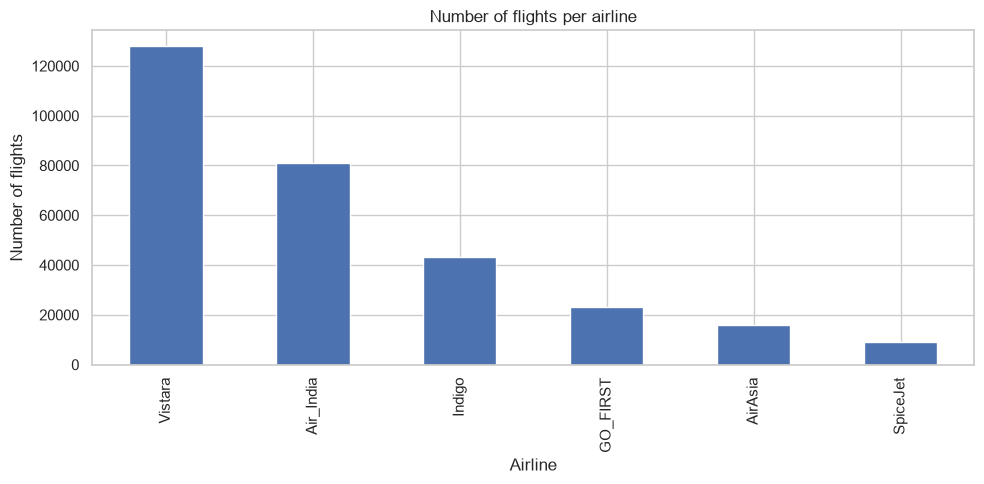

In [8]:
# Create a bar chart showing the number of flights per airline.
# This tells us whether the dataset is balanced across airlines or dominated by one carrier.
#
# Steps:
#   1. Use df['Airline'].value_counts() to get the counts.
#   2. Call .plot(kind='bar') on the result, or use sns.countplot.
#   3. Add a title and axis labels with plt.title(), plt.xlabel(), plt.ylabel().
#   4. Call plt.tight_layout() so labels don't get clipped.
#   5. Call plt.show().

df['airline'].value_counts().plot(kind='bar')
plt.title('Number of flights per airline')
plt.xlabel('Airline')
plt.ylabel('Number of flights')
plt.tight_layout()
plt.show()


### 2c — NumPy: manual statistical analysis of Price

pandas `.describe()` is convenient, but in this section you will compute the same statistics yourself using NumPy. The goal is to understand *what these statistics actually are*, not just read them off a table.

> **Key NumPy functions to know:**  
> `np.mean()`, `np.median()`, `np.std()`, `np.percentile()`, `np.min()`, `np.max()`, `np.abs()`, `np.where()`
>
> Docs: [numpy.org/doc/stable/reference/routines.statistics.html](https://numpy.org/doc/stable/reference/routines.statistics.html)

In [9]:
# Extract the Price column as a NumPy array so we can do array-level math on it.
prices = df['price'].to_numpy()

# Compute and print each of the following using NumPy (do NOT use df.describe() here):
#   - Mean price
#   - Median price
#   - Standard deviation
#   - Minimum and maximum price
#   - 25th percentile (Q1) and 75th percentile (Q3)
#   - Interquartile Range (IQR) = Q3 - Q1

mean_price   = np.mean(prices)
median_price = np.median(prices)
std_price    = np.std(prices)
min_price    = np.min(prices)
max_price    = np.max(prices)
q1           = np.percentile(prices, 25)
q3           = np.percentile(prices, 75)
iqr          = q3 - q1

print(f'Mean:    {mean_price:.2f}')
print(f'Median:  {median_price:.2f}')
print(f'Std dev: {std_price:.2f}')
print(f'Min:     {min_price:.2f}')
print(f'Max:     {max_price:.2f}')
print(f'Q1:      {q1:.2f}')
print(f'Q3:      {q3:.2f}')
print(f'IQR:     {iqr:.2f}')

Mean:    20889.66
Median:  7425.00
Std dev: 22697.73
Min:     1105.00
Max:     123071.00
Q1:      4783.00
Q3:      42521.00
IQR:     37738.00


In [10]:
# Identify outliers in Price using the IQR method.
#
# The rule: a value is an outlier if it falls below (Q1 - 1.5 * IQR)
#                                              or above (Q3 + 1.5 * IQR).
#
# Steps:
#   1. Compute the lower and upper fence values.
#   2. Use np.where() (or boolean indexing) to find which prices fall outside those fences.
#   3. Print how many outliers exist and what fraction of the data they represent.
#
# We are NOT removing these outliers yet — in Deliverable 2 we will decide whether to
# remove, cap, or keep them. For now we just want to know they exist.

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

# Boolean array: True where the price is an outlier
is_outlier = (prices < lower_fence) | (prices > upper_fence)

print(f'Outliers: {is_outlier.sum()} ({100 * is_outlier.mean():.1f}% of rows)')

Outliers: 123 (0.0% of rows)


### 2d — Visualisations

A picture is worth a thousand `print()` statements. Below you will build three key plots. Each one answers a different question about the data.

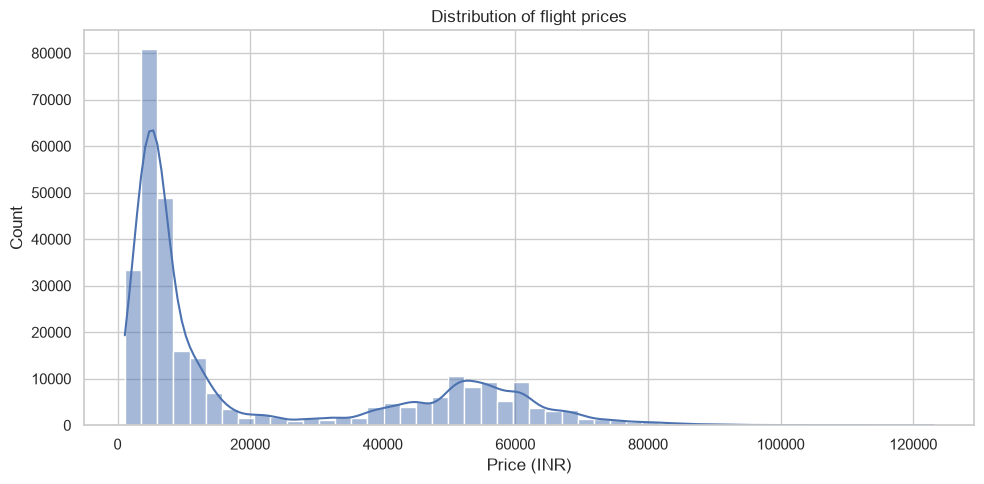

In [11]:
# Plot a histogram of the Price column to see its distribution.
#
# A right-skewed distribution (long tail to the right) is common for prices —
# most flights are cheap, but a few are very expensive.
#
# Hint: use plt.hist(prices, bins=50) or sns.histplot(df['Price'], bins=50, kde=True)
# kde=True adds a smooth density curve on top of the histogram.
#
# Add a title, x-label ('Price (INR)'), and y-label ('Count').
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of flight prices')
plt.xlabel('Price (INR)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


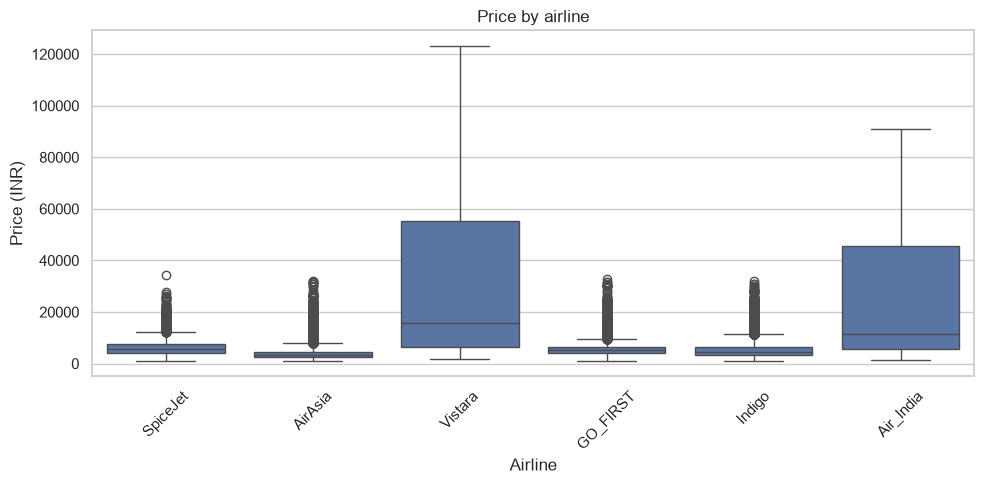

In [12]:
# Create a box plot of Price grouped by Airline.
#
# A box plot shows median, quartiles, and outliers for each group side-by-side.
# This tells us: do different airlines charge systematically different prices?
#
# Hint: sns.boxplot(data=df, x='Airline', y='Price')
#       plt.xticks(rotation=45) rotates the x-axis labels so they don't overlap.
sns.boxplot(data=df, x='airline', y='price')
plt.xticks(rotation=45)
plt.title('Price by airline')
plt.xlabel('Airline')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()


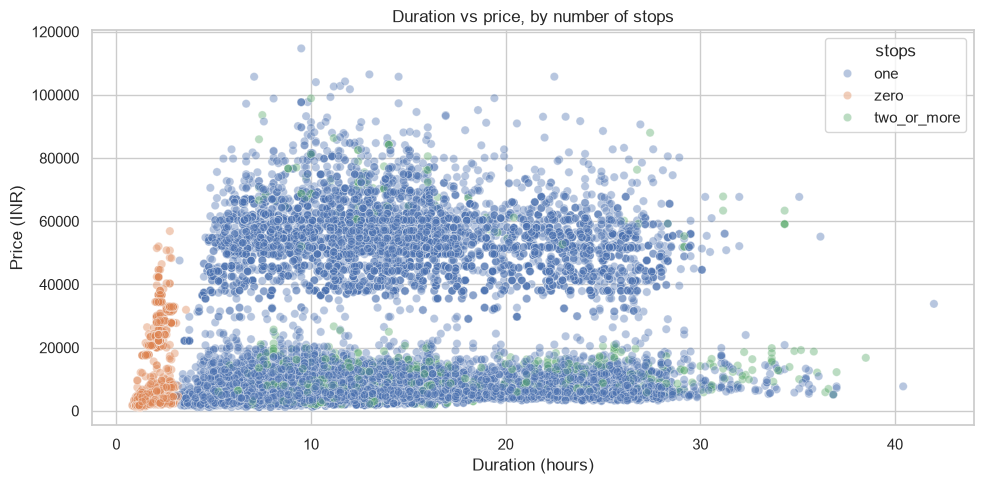

In [13]:
# Create a scatter plot of Duration (x-axis) vs Price (y-axis),
# with points coloured by the Stops column.
#
# This helps us see whether longer flights tend to be more expensive,
# and whether the number of stops explains price beyond duration alone.
#
# Hint: sns.scatterplot(data=df, x='Duration', y='Price', hue='Stops', alpha=0.4)
#       alpha < 1 makes points semi-transparent so overlapping points are visible.
sns.scatterplot(data=df.sample(20000, random_state=42),
                x='duration', y='price', hue='stops', alpha=0.4)
plt.title('Duration vs price, by number of stops')
plt.xlabel('Duration (hours)')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()


---
## Section 3 — Feature engineering & preprocessing

**Goal:** Transform the raw DataFrame into a form the XGBoost model can consume.

Machine learning models work on numbers, not strings. We need to:
1. Drop columns that carry no predictive signal (e.g. the flight code).
2. Encode the categorical text columns as integers.
3. Separate the feature matrix **X** from the target vector **y**.
4. Split into train and test sets.

> **Docs to read:**  
> - [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)  
> - [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

---
### 3a — Drop uninformative columns

In [14]:
# Drop the 'Flight' column from df.
#
# Why drop it? The flight code (e.g. 'UK-706') is just an identifier — it won't generalise
# to unseen flights and would just introduce noise. Always ask: "Does this feature carry
# real information about the target, or is it just a label?"
#
# Hint: df.drop(columns=['Flight'], inplace=True)
df.drop(columns=['flight', 'Unnamed: 0'], inplace=True)


# Print the remaining column names to confirm.
print(df.columns.tolist())

['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


### 3b — Encode categorical columns

XGBoost cannot accept string values directly. We need to convert each categorical column to integers.

`LabelEncoder` assigns a unique integer to each category: e.g. {"Economy": 0, "Business": 1}. This is simple and works well for tree-based models (unlike linear models, which would misinterpret the ordering of integers — that's a subtlety you'll learn more about in Deliverable 2).

In [15]:
# These are the columns that still contain strings after we dropped 'Flight'.
categorical_cols = ['airline', 'source_city', 'departure_time',
                    'stops', 'arrival_time', 'destination_city', 'class']

# We create one LabelEncoder per column and store them in a dict.
# Storing encoders lets us inverse_transform predictions later
# (turn integers back into readable category names).
encoders = {}

# Loop over categorical_cols.
#   For each column:
#     1. Instantiate a LabelEncoder: `le = LabelEncoder()`
#     2. Fit and transform the column: `df[col] = le.fit_transform(df[col])`
#     3. Store the encoder: `encoders[col] = le`
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


# Sanity check: the dtypes of the encoded columns should now be integers.
print(df[categorical_cols].dtypes)

airline             int64
source_city         int64
departure_time      int64
stops               int64
arrival_time        int64
destination_city    int64
class               int64
dtype: object


### 3c — Separate features and target, then split

In [16]:
# Create X (feature matrix) and y (target vector).
#   X = all columns EXCEPT 'Price'
#   y = the 'Price' column
#
# Hint for X: df.drop(columns=['Price'])

X = df.drop(columns=['price'])
y = df['price']

print('Feature matrix shape:', X.shape)   # should be (n_rows, 9)
print('Target vector shape: ', y.shape)   # should be (n_rows,)

Feature matrix shape: (300153, 9)
Target vector shape:  (300153,)


In [17]:
# Split X and y into training and test sets.
#
# Use an 80/20 split: 80% of the data for training, 20% held out for testing.
# Set random_state=42 so your split is reproducible — anyone who runs this notebook
# will get the same split, which is essential for fair comparisons.
#
# Hint: train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')

Training set:  240122 rows
Test set:      60031 rows


---
## Section 4 — XGBoost model training

**Goal:** Train an XGBoost regression model and inspect which features it finds most important.

### What is XGBoost?

XGBoost (eXtreme Gradient Boosting) is an **ensemble method** — it combines many simple decision trees into one powerful model. Here's the key idea:

1. Fit a shallow decision tree on the data. It will make errors (residuals).
2. Fit a second tree to *correct the errors* of the first.
3. Fit a third tree to correct the errors of the first two. And so on.
4. The final prediction is the sum of all the trees' outputs.

This sequential error-correction process is called **gradient boosting**. XGBoost adds engineering tricks (second-order gradients, regularisation, column sub-sampling) that make it extremely fast and accurate.

**Key hyperparameters to know:**

| Parameter | What it controls |
|---|---|
| `n_estimators` | Number of trees to build. More trees = more capacity, but slower and potentially overfit. |
| `max_depth` | Maximum depth of each tree. Deeper trees can capture more complexity but overfit more. |
| `learning_rate` | How much each new tree is "trusted". Lower = more conservative, often needs more trees. |
| `subsample` | Fraction of training rows to use for each tree. Adds randomness, helps prevent overfitting. |
| `colsample_bytree` | Fraction of features to consider at each split. Like `subsample` but for columns. |

> **Docs:** [XGBRegressor API](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor)

---

In [18]:
# Create an XGBRegressor with the following settings:
#   n_estimators=300     — we will build 300 trees
#   max_depth=6          — each tree can be at most 6 levels deep
#   learning_rate=0.1    — a common default starting point
#   subsample=0.8        — use 80% of the training data per tree
#   colsample_bytree=0.8 — use 80% of the features per tree
#   random_state=42      — for reproducibility
#
# Then fit (train) the model on X_train and y_train.
# Fitting means the model will run through all 300 trees, learning from the training data.

model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42)

# Fit the model — model.fit(X_train, y_train)
model.fit(X_train, y_train)


print('Model trained!')

Model trained!


class               0.784037
airline             0.123090
stops               0.053240
duration            0.012779
days_left           0.009582
destination_city    0.005734
source_city         0.005417
arrival_time        0.003555
departure_time      0.002567
dtype: float32


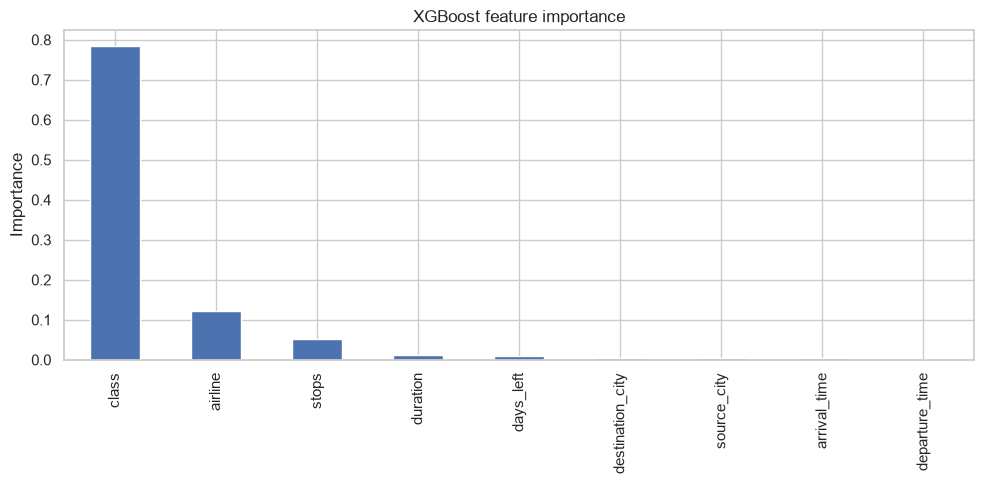

In [19]:
# Feature importance: XGBoost tracks how often each feature was used in a split
# and how much each split reduced the prediction error.
# 'gain' (the default) measures the average improvement in accuracy each feature provides.

# Plot the feature importances using xgb.plot_importance(model).
# Set importance_type='gain' to use the 'gain' metric.
# Add a title: 'Feature Importances (gain)'
#
# Which feature is most important? Does that match your intuition from the EDA?
# Write your answer in the markdown cell below.
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

importances.plot(kind='bar')
plt.title('XGBoost feature importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

**Answer:** The most important feature is **class** (Economy vs Business) at about 0.78, far ahead of **airline** (about 0.12) and **stops** (about 0.05). This matches my EDA: the price histogram has two clusters, and Business tickets cost several times more than Economy ones, so class separates prices more than anything else. Duration and days_left have small importance (about 0.01 each).

---
## Section 5 — Model evaluation

**Goal:** Measure how well our model performs on the *test set* — data it has never seen during training.

We use three complementary metrics:

- **MAE (Mean Absolute Error):** On average, how many INR off is our prediction? Easy to interpret: an MAE of 2,000 means we're off by ₹2,000 per ticket on average.
- **RMSE (Root Mean Squared Error):** Like MAE but penalises large errors more heavily (because errors are squared before averaging). If RMSE >> MAE, we have a few very bad predictions.
- **R² (R-squared):** The fraction of variance in price that our model explains. An R² of 0.95 means we explain 95% of the variation — a perfect model would score 1.0.

> **Docs:** [sklearn.metrics](https://scikit-learn.org/stable/modules/model_evaluation.html)

In [20]:
# Generate predictions on the test set.
# Hint: y_pred = model.predict(X_test)

y_pred = model.predict(X_test)

# Calculate MAE, RMSE, and R² and print them.
#
# mean_absolute_error(y_test, y_pred)
# np.sqrt(mean_squared_error(y_test, y_pred))  — note: take sqrt to get RMSE from MSE
# r2_score(y_test, y_pred)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²:   {r2:.4f}')

MAE:  2115.72
RMSE: 3676.98
R²:   0.9738


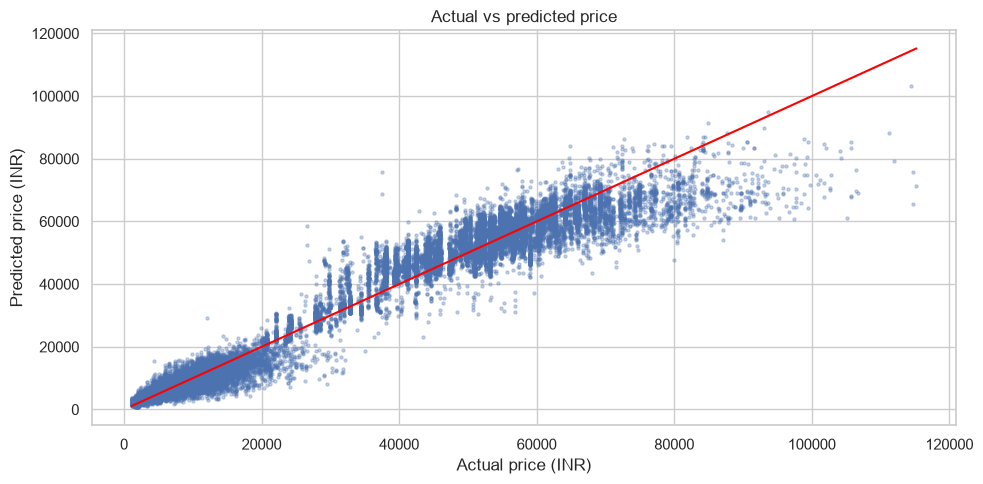

In [21]:
# Create an "Actual vs Predicted" scatter plot.
#
# Plot y_test on the x-axis and y_pred on the y-axis.
# Add a diagonal reference line (y = x) — if our model were perfect, all points would
# fall exactly on this line. Points above the line = we over-predicted; below = under-predicted.
#
# Steps:
#   1. plt.scatter(y_test, y_pred, alpha=0.3, s=10)  — the predictions
#   2. Compute a range for the reference line:
#      min_val = min(y_test.min(), y_pred.min())
#      max_val = max(y_test.max(), y_pred.max())
#      plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
#   3. Add axis labels ('Actual Price (INR)', 'Predicted Price (INR)'), a title, and a legend.
plt.scatter(y_test, y_pred, alpha=0.3, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.title('Actual vs predicted price')
plt.xlabel('Actual price (INR)')
plt.ylabel('Predicted price (INR)')
plt.tight_layout()
plt.show()

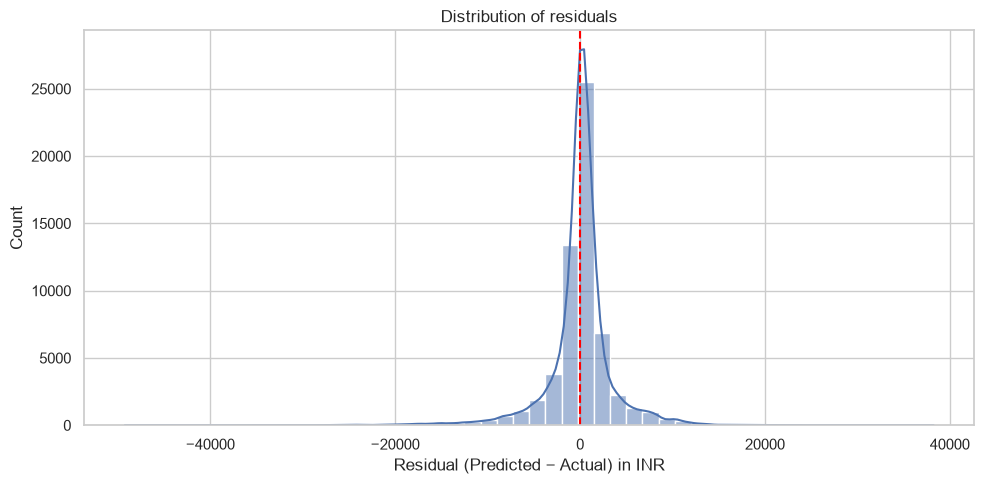

In [22]:
# Plot the residuals (errors) as a histogram.
#
# Residuals = y_pred - y_test
# For a well-behaved model, residuals should be roughly centred around 0 
# (we're not systematically over- or under-predicting) and approximately symmetric.
#
# Hint: sns.histplot(y_pred - y_test, bins=50, kde=True)
# Add a vertical line at 0: plt.axvline(0, color='red', linestyle='--')
# Label it: 'Residual (Predicted − Actual) in INR'
residuals = y_pred - y_test

sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of residuals')
plt.xlabel('Residual (Predicted − Actual) in INR')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



---
## Section 6 — Reflection

Answer each question in the cell below it. **Write in your own words** — these are thinking prompts, not exam questions. There is no single correct answer.

---

**Q1.** Based on your feature importance plot, which 2–3 features drive the price prediction the most? Why do you think those features matter for flight prices?

**Answer Q1:** The features that drive the prediction most are **class**, **airline** and **stops**. Class is by far the largest (about 78% of the importance), because Business tickets cost much more than Economy, which is the main split in the price histogram. Airline (about 12%) matters because carriers price differently, for example full-service vs budget, which the box plot showed. Stops (about 5%) matters because one-stop and non-stop flights are priced differently. Duration and days_left were much less important than I expected (about 1% each), probably because class and airline already explain most of the price differences.

**Q2.** Look at your actual-vs-predicted scatter plot. Are there any regions (high prices, low prices, specific price ranges) where the model struggles more? What might cause that?

**Answer Q2:** The model does best on cheaper flights and struggles most on **high-priced flights** (above roughly 60,000 INR), where it tends to **under-predict**. In the actual-vs-predicted plot the points follow the red diagonal at low and mid prices but spread out below it at the top. Possible causes: there are far fewer expensive flights in the data, so the model sees fewer examples, and expensive prices depend on combinations of things (Business class, airline, stops) that are harder to learn. The residual histogram is centred on 0 but has long tails for the same reason.

**Q3.** We used `LabelEncoder` to encode categorical columns. What is one limitation of this approach for a feature like `Airline`? How might you encode it differently? *(Hint: look up "one-hot encoding" if you are unsure.)*

**Answer Q3:** LabelEncoder turns each airline into an integer, like AirAsia = 0, Indigo = 1, Vistara = 2. Numbers imply an order and a distance, and airlines have neither. It looks like Vistara is "bigger" than Indigo. Tree models like XGBoost cope with this better than linear models, but it still imposes an arbitrary order. One-hot encoding fixes this by giving each airline its own 0/1 column, so no order is implied.



**Q4.** Name **one thing you would try next** to improve this model's R² score. You don't have to implement it — just describe the idea and why you think it would help.

**Answer Q4:** I would try one-hot encoding the categorical columns instead of label encoding. I think it would help because the model could then treat each airline and city as its own category, without an artificial order, and learn their effects separately. I'd then compare R² before and after.




**Q5 — Git reflection.** In your own words, explain:
- Why did we create a new branch (`deliverable1/<your-name>`) instead of working directly on `main`?
- What would happen if two people both pushed directly to `main` at the same time?

**Answer Q5:** We create a branch instead of working on main so unfinished or broken work doesn't affect the shared code. main stays in a known-good state, and changes are reviewed before they're merged. If two people push to the same branch at the same time, the second push is rejected because the branch has changed. That person has to pull first and merge, and if both edited the same lines (easy in a notebook) there's a merge conflict to resolve. In our project we also learned that Git can't have both team-04 and team-04/name, because a branch can't also be a folder.



---
## Before you submit — final checklist

1. **Restart & Run All** (Kernel → Restart & Run All) — confirm the notebook runs top-to-bottom with no errors.
2. Every `# TODO` cell has been filled in.
3. All five reflection questions are answered.
4. The file `deliverable1/data/Clean_Dataset.csv` is **not** staged (`git status` should not show it).
5. Commit only `deliverable1/flight_price_prediction.ipynb`:
   ```sh
   git add deliverable1/flight_price_prediction.ipynb
   git commit -m "deliverable1: complete EDA and XGBoost starter notebook"
   git push
   ```
6. Open a **pull request** on GitHub from your branch into `main`. Use the PR template. Tag a PM for review.

Nice work. See you in Deliverable 2 — we'll go much deeper on feature engineering and model tuning. 🚀